In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [2]:
print('1. Loading data...')

try:
    df = pd.read_csv('mlb-batter-exit-velocity.csv')
except FileNotFoundError:
    print('ERROR: File not found, please make sure the file is in the correct directory')
    df = pd.DataFrame() #Create empty DataFrame to prevent errors
if not df.empty:
    print('Data loaded successfully. Initial Data Head:')
    print(df.head())

1. Loading data...
Data loaded successfully. Initial Data Head:
   id  rank  year               player  batted_ball_events  launch_angle  \
0   1     1  2022         Judge, Aaron                 341          14.6   
1   2     2  2022      Alvarez, Yordan                 304          12.1   
2   3     3  2022          Trout, Mike                 234          24.7   
3   4     4  2022      Schwarber, Kyle                 312          18.9   
4   5     5  2022   Stanton, Giancarlo                 228          10.2   

   sweet_spot_percentage  max_ev  average_ev  fly_ball_line_drive_ev  \
0                   37.8   118.4        95.8                   100.2   
1                   40.1   117.4        95.5                    98.2   
2                   37.2   114.4        91.7                    94.9   
3                   34.6   114.8        93.3                    99.7   
4                   26.3   119.8        94.6                    98.2   

   ground_ball_ev  max_distance  average_dista

In [3]:
print("2. Data Cleaning and preparation...")

#Renaming key columns for code clarity
df = df.rename(columns={
    'average_ev' : 'ev_avg',
    'launch_angle' : 'la_avg',
    'average_distance' : 'dist_avg'
})
#Handle missing values by filling NAs with the mean
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

#Filter to players with meaningful data(>100 batted ball events)
df_filtered = df[df['batted_ball_events'] > 100].copy()

dist_avg = 'dist_avg'
print('Target Variable: dist_avg (Average Distance of Batted Balls)')

2. Data Cleaning and preparation...
Target Variable: dist_avg (Average Distance of Batted Balls)


In [4]:
print('3. Defining Features and Preprocessing...')

features = [
    'ev_avg',
    'la_avg',
    'barrels_batted_balls_percentage',
    'hard_hit_percentage',
]

X = df_filtered[features]
y = df_filtered[dist_avg]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

3. Defining Features and Preprocessing...
Training set size: 1534, Test set size: 384


In [5]:
print('4. Model Training (Multi-Linear Regression)...')

linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)

print("Multi-Linear Regression Model training complete.")

4. Model Training (Multi-Linear Regression)...
Multi-Linear Regression Model training complete.


In [6]:
print('5. Model Evaluation')

y_pred = linreg_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (R2) Score: {r2:.4f} ")
print(f"Root Mean Squared Error (RMSE): {rmse:.4F}")

5. Model Evaluation
R-squared (R2) Score: 0.7892 
Root Mean Squared Error (RMSE): 9.5295


6. Correlation Analysis Summary and Visualization...


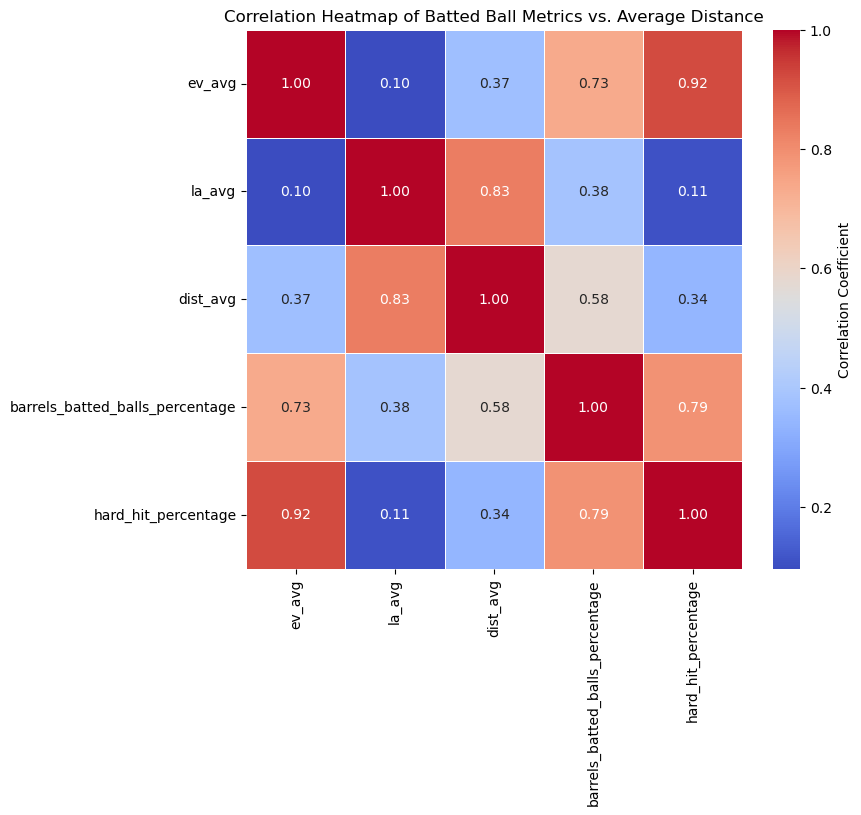

Simple Correlation Matrix (LA/EV vs. Average Distance):
dist_avg                           1.000000
la_avg                             0.831515
barrels_batted_balls_percentage    0.579541
ev_avg                             0.368497
hard_hit_percentage                0.340958
Name: dist_avg, dtype: float64


In [7]:
print('6. Correlation Analysis Summary and Visualization...')

heatmap_cols = ['ev_avg', 'la_avg', dist_avg, 'barrels_batted_balls_percentage', 'hard_hit_percentage']
correlation_matrix = df_filtered[heatmap_cols].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Batted Ball Metrics vs. Average Distance')
plt.show()

print("Simple Correlation Matrix (LA/EV vs. Average Distance):")
print(correlation_matrix[dist_avg].sort_values(ascending=False))

7. Interpretability (Model Coefficients - XAI)...


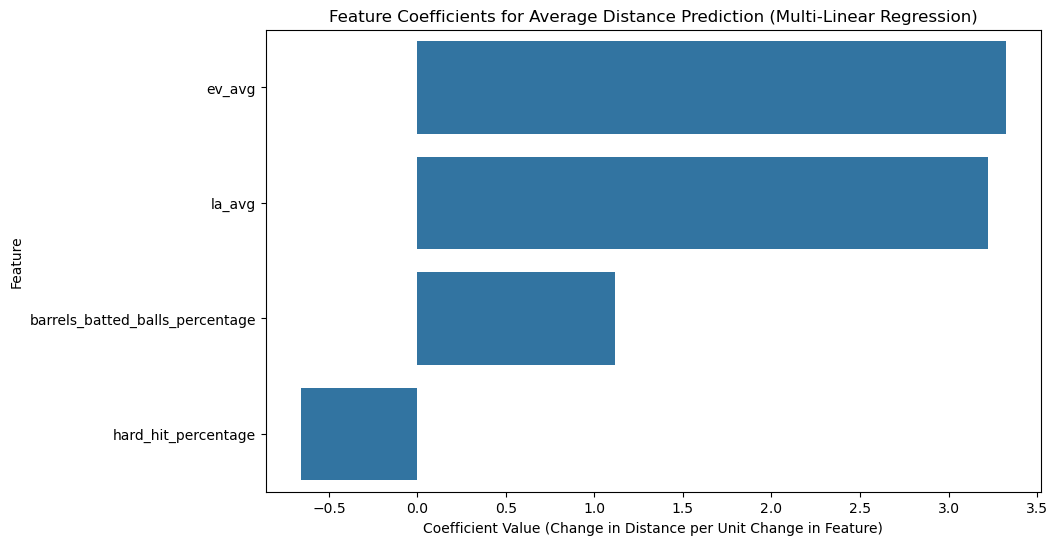


Model Coefficients:
ev_avg                             3.322140
la_avg                             3.223287
barrels_batted_balls_percentage    1.115905
hard_hit_percentage               -0.657460
dtype: float64

Model Intercept: -147.47


In [8]:
print("7. Interpretability (Model Coefficients - XAI)...")
    
# Extract coefficients (marginal contribution/importance for Linear Regression)
coefficients = pd.Series(linreg_model.coef_, index=features).sort_values(ascending=False)
    
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients.values, y=coefficients.index)
plt.title('Feature Coefficients for Average Distance Prediction (Multi-Linear Regression)')
plt.xlabel('Coefficient Value (Change in Distance per Unit Change in Feature)')
plt.ylabel('Feature')
plt.show()
    
print("\nModel Coefficients:")
print(coefficients)
print(f"\nModel Intercept: {linreg_model.intercept_:.2f}")

8. Correlation Analysis Summary
Simple Correlation Matrix (LA/EV vs. Average Distance):
            ev_avg    la_avg  dist_avg
ev_avg    1.000000  0.096066  0.368497
la_avg    0.096066  1.000000  0.831515
dist_avg  0.368497  0.831515  1.000000


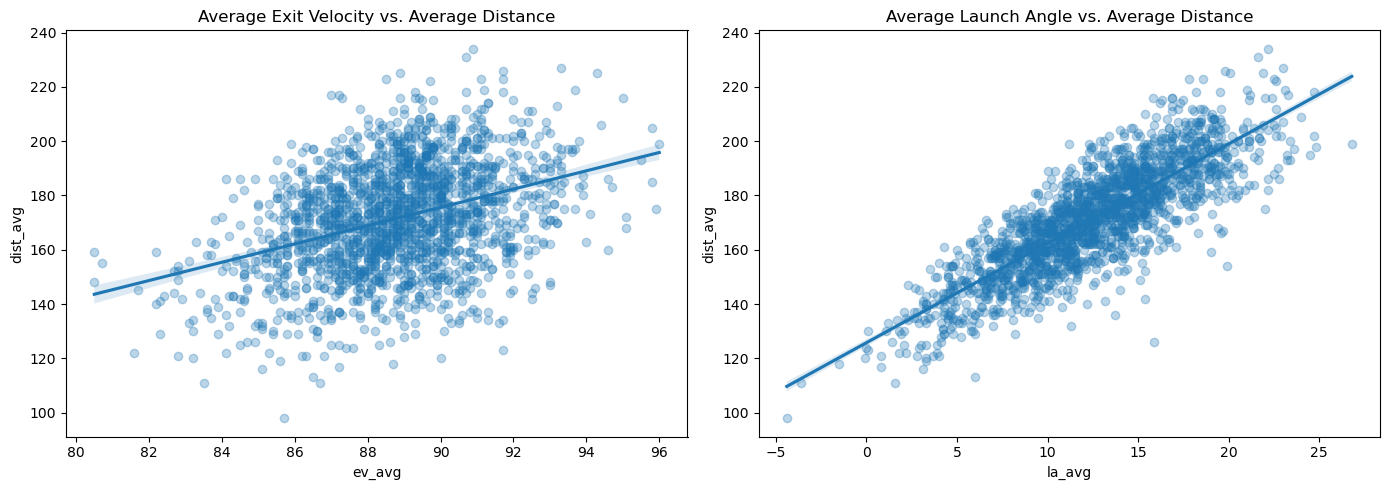


--- Conclusion & Ethical Reflection ---
The R2 score of 0.7892 indicates how much of the variance in a player's average batted ball distance is explained by these four factors.
The model coefficients (XAI) show the marginal impact of each factor, providing a quantifiable correlation.
As noted in the proposal, these results must be interpreted cautiously (XAI) to avoid bias in player evaluation.


In [9]:
print('8. Correlation Analysis Summary')
    
# Calculate the simple correlation matrix for the primary variables and target
correlation_data = df_filtered[['ev_avg', 'la_avg', dist_avg]].corr()
print("Simple Correlation Matrix (LA/EV vs. Average Distance):")
print(correlation_data)

# Visualizing the relationship between the primary features and the target
plt.figure(figsize=(14, 5))
    
plt.subplot(1, 2, 1)
sns.regplot(x='ev_avg', y=dist_avg, data=df_filtered, scatter_kws={'alpha':0.3})
plt.title(f'Average Exit Velocity vs. Average Distance')
    
plt.subplot(1, 2, 2)
sns.regplot(x='la_avg', y=dist_avg, data=df_filtered, scatter_kws={'alpha':0.3})
plt.title(f'Average Launch Angle vs. Average Distance')
    
plt.tight_layout()
plt.show()
    
# Final Interpretation Note:
print("\n--- Conclusion & Ethical Reflection ---")
print(f"The R2 score of {r2:.4f} indicates how much of the variance in a player's average batted ball distance is explained by these four factors.")
print("The model coefficients (XAI) show the marginal impact of each factor, providing a quantifiable correlation.")
print("As noted in the proposal, these results must be interpreted cautiously (XAI) to avoid bias in player evaluation.")